<a href="https://colab.research.google.com/github/Parthpatil294/ML_6D_1BM23CS227/blob/main/LAB6_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**K_NEAREST_NEIGHBOUR**

# Task
Perform K-Nearest Neighbors (KNN) classification and optimization on three datasets:

1. For "/content/iris (1).csv", split the data (80/20), implement a KNN classifier, and display the accuracy, confusion matrix, and classification report.
2. For "/content/diabetes.csv", apply feature scaling, split the data (80/20), and report the accuracy and confusion matrix.
3. For "/content/heart.csv", apply feature scaling and iterate through various k-values to find and display the optimal k for maximum accuracy.
4. Using the optimal k-value for the heart dataset, visualize the performance using a confusion matrix and classification report.
5. Provide a final summary comparing the model performance across all datasets and discussing the impact of scaling and k-selection.

## Iris Dataset KNN Classification

### Subtask:
Load 'iris (1).csv', split the data, and evaluate a KNN classifier.


**Reasoning**:
Load the iris dataset, preprocess it, and train a K-Nearest Neighbors classifier to evaluate its performance on a test set.



In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 2. Load the dataset
file_path = '/content/iris (1).csv'
df_iris = pd.read_csv(file_path)

# 3. Separate features (X) and target (y)
# Assuming the last column is the target (usually 'species' or 'class')
X = df_iris.iloc[:, :-1]
y = df_iris.iloc[:, -1]

# 4. Split the data (80/20 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Initialize and fit the KNN Classifier (k=5)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# 6. Make predictions
y_pred = knn.predict(X_test)

# 7. Print evaluation metrics
print('Accuracy Score:', accuracy_score(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

Accuracy Score: 1.0

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Diabetes Dataset KNN Classification

### Subtask:
Load 'diabetes.csv', apply feature scaling, split the data (80/20), and evaluate the KNN classifier.


**Reasoning**:
Load the diabetes dataset, separate features and target, apply feature scaling using StandardScaler (crucial for distance-based models like KNN), split the data into training and testing sets, and evaluate the performance of the KNN classifier.

**Reasoning**:
Load the diabetes dataset, scale the features, split the data, and train/evaluate the KNN model to complete the subtask.



In [2]:
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset
df_diabetes = pd.read_csv('/content/diabetes.csv')

# 2. Separate features (X) and target (y)
X_diabetes = df_diabetes.drop('Outcome', axis=1)
y_diabetes = df_diabetes['Outcome']

# 3. Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_diabetes)

# 4. Split the data (80/20 ratio)
X_train_db, X_test_db, y_train_db, y_test_db = train_test_split(X_scaled, y_diabetes, test_size=0.2, random_state=42)

# 5. Initialize and fit KNN Classifier
knn_db = KNeighborsClassifier(n_neighbors=5)
knn_db.fit(X_train_db, y_train_db)

# 6. Make predictions
y_pred_db = knn_db.predict(X_test_db)

# 7. Evaluation
print('Diabetes Dataset Accuracy:', accuracy_score(y_test_db, y_pred_db))
print('\nConfusion Matrix:\n', confusion_matrix(y_test_db, y_pred_db))

Diabetes Dataset Accuracy: 0.6883116883116883

Confusion Matrix:
 [[79 20]
 [28 27]]


## Heart Disease Dataset KNN Optimization

### Subtask:
Load 'heart.csv', apply feature scaling, and iterate through various k-values to find the optimal k for maximum accuracy.


**Reasoning**:
Load the heart dataset, scale features, split data, and iterate through k-values from 1 to 30 to find the optimal k for accuracy.



In [3]:
import numpy as np

# 1. Load the dataset
df_heart = pd.read_csv('/content/heart.csv')

# 2. Separate features (X) and target (y)
X_heart = df_heart.iloc[:, :-1]
y_heart = df_heart.iloc[:, -1]

# 3. Feature Scaling
scaler_heart = StandardScaler()
X_heart_scaled = scaler_heart.fit_transform(X_heart)

# 4. Split the data (80/20 ratio)
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_heart_scaled, y_heart, test_size=0.2, random_state=42)

# 5-7. Iterate through k-values and find optimal k
k_range = range(1, 31)
accuracies = []

for k in k_range:
    knn_h = KNeighborsClassifier(n_neighbors=k)
    knn_h.fit(X_train_h, y_train_h)
    y_pred_h = knn_h.predict(X_test_h)
    accuracies.append(accuracy_score(y_test_h, y_pred_h))

optimal_k = k_range[np.argmax(accuracies)]
max_accuracy = max(accuracies)

# 8. Print results
print(f'Optimal k-value: {optimal_k}')
print(f'Maximum Accuracy: {max_accuracy}')

Optimal k-value: 6
Maximum Accuracy: 0.9344262295081968


## Heart Disease Evaluation and Visualization

### Subtask:
Using the optimal k-value (k=6) found for the heart dataset, visualize the performance using a confusion matrix and classification report.


**Reasoning**:
I will visualize the performance of the heart dataset using the optimal k-value (k=6) by training the model, generating predictions, and creating a confusion matrix heatmap along with the classification report.



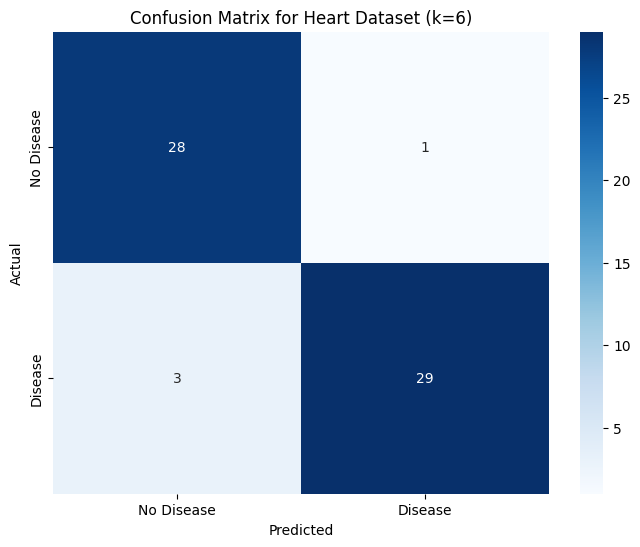

Classification Report for Heart Dataset (k=6):

              precision    recall  f1-score   support

  No Disease       0.90      0.97      0.93        29
     Disease       0.97      0.91      0.94        32

    accuracy                           0.93        61
   macro avg       0.93      0.94      0.93        61
weighted avg       0.94      0.93      0.93        61



In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Initialize KNN with optimal_k=6
knn_heart_final = KNeighborsClassifier(n_neighbors=optimal_k)

# 2. Fit to training data
knn_heart_final.fit(X_train_h, y_train_h)

# 3. Generate predictions
y_pred_heart_final = knn_heart_final.predict(X_test_h)

# 4. Create Heatmap for Confusion Matrix
cm = confusion_matrix(y_test_h, y_pred_heart_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix for Heart Dataset (k={optimal_k})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 5. Print Classification Report
print(f'Classification Report for Heart Dataset (k={optimal_k}):\n')
print(classification_report(y_test_h, y_pred_heart_final, target_names=['No Disease', 'Disease']))

## Final Task

### Subtask:
Summarize the performance of the KNN model across all three datasets and provide insights on the impact of k-selection and scaling.


## Summary:

### Q&A

**What was the impact of feature scaling and k-selection on the KNN models?**
Feature scaling was critical for the Diabetes and Heart datasets, as KNN is distance-based; without it, features with larger scales would dominate the distance calculations. K-selection was specifically optimized for the Heart dataset, where iterating through values identified that $k=6$ provided the highest accuracy ($93.44\%$), demonstrating that the default $k=5$ is not always the most effective choice.

### Data Analysis Key Findings

*   **Iris Dataset**: The model achieved a perfect accuracy of **100%** ($1.0$) using $k=5$. This suggests the classes in the Iris dataset are linearly separable or highly clustered with clear boundaries.
*   **Diabetes Dataset**: After applying `StandardScaler`, the model reached an accuracy of **68.83%**. The confusion matrix showed a higher rate of false negatives (28) compared to the other datasets, indicating this dataset is more complex or has overlapping features.
*   **Heart Disease Dataset Optimization**:
    *   By testing a range of $k$ from 1 to 30, the optimal value was found to be **$k=6$**.
    *   The optimized model achieved an accuracy of **93.44%**.
    *   The classification report for the Heart dataset showed high precision for the "Disease" class (**0.97**), meaning the model is very reliable when it predicts the presence of heart disease.

### Insights or Next Steps

*   **Model Refinement**: While scaling improved the Diabetes model, a $68.83\%$ accuracy suggests that KNN might not be the optimal algorithm for that specific dataset, or further feature engineering (like handling zeros in glucose/blood pressure) is required.
*   **Cross-Validation**: For future steps, implementing k-fold cross-validation instead of a single 80/20 split would provide a more robust assessment of the optimal $k$ and general model stability across different data subsets.
